In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "remoed for privacy"

In [ ]:
!mkdir -p ~/.kaggle
!echo "removed for privacy" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [ ]:
path = kagglehub.competition_download('dogs-vs-cats')

100%|██████████| 812M/812M [00:06<00:00, 126MB/s]

Extracting files...


In [ ]:
import os

file=os.listdir(path)
print(file)

['test1.zip', 'train.zip', 'sampleSubmission.csv']


In [ ]:
import zipfile

zip_path = path+"/test1.zip"
extract_path = "/tested"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:


file=os.listdir("/train")

In [ ]:
print(file)

['cat.1721.jpg', 'dog.10464.jpg', 'cat.8203.jpg', 'dog.6718.jpg', 'cat.11986.jpg', 'dog.72.jpg', 'cat.496.jpg', 'dog.2401.jpg', 'cat.1828.jpg', 'cat.8000.jpg', 'dog.3402.jpg', 'dog.946.jpg', 'dog.10051.jpg', 'cat.58.jpg', 'cat.7159.jpg', 'dog.10118.jpg', 'dog.4653.jpg', 'cat.2052.jpg', 'cat.8043.jpg', 'dog.5115.jpg', 'cat.6565.jpg', 'cat.6269.jpg', 'dog.429.jpg', 'cat.3343.jpg', 'cat.2371.jpg', 'dog.12161.jpg', 'dog.10049.jpg', 'dog.1302.jpg', 'dog.9154.jpg', 'dog.5985.jpg', 'dog.11132.jpg', 'dog.9054.jpg', 'cat.6180.jpg', 'cat.7022.jpg', 'cat.12173.jpg', 'dog.10214.jpg', 'cat.1980.jpg', 'cat.9625.jpg', 'dog.9634.jpg', 'dog.5083.jpg', 'cat.7694.jpg', 'cat.1943.jpg', 'dog.7775.jpg', 'cat.12089.jpg', 'dog.8939.jpg', 'dog.2555.jpg', 'cat.437.jpg', 'dog.10685.jpg', 'dog.345.jpg', 'dog.5220.jpg', 'dog.11951.jpg', 'dog.7916.jpg', 'dog.2948.jpg', 'cat.10900.jpg', 'cat.896.jpg', 'cat.9629.jpg', 'dog.12387.jpg', 'cat.6107.jpg', 'cat.2679.jpg', 'dog.529.jpg', 'cat.1248.jpg', 'dog.9520.jpg', 'cat

In [ ]:
import os
import shutil

source_dir = "/train"

cats_dir = "/dataset/cats"
dogs_dir = "/dataset/dogs"

os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

for filename in os.listdir(source_dir):

    src = os.path.join(source_dir, filename)

    if filename.startswith("cat"):
        shutil.copy(src, os.path.join(cats_dir, filename))

    elif filename.startswith("dog"):
        shutil.copy(src, os.path.join(dogs_dir, filename))

print("Dataset organized successfully!")

Dataset organized successfully!


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [ ]:
print(train_ds.class_names)

['cats', 'dogs']


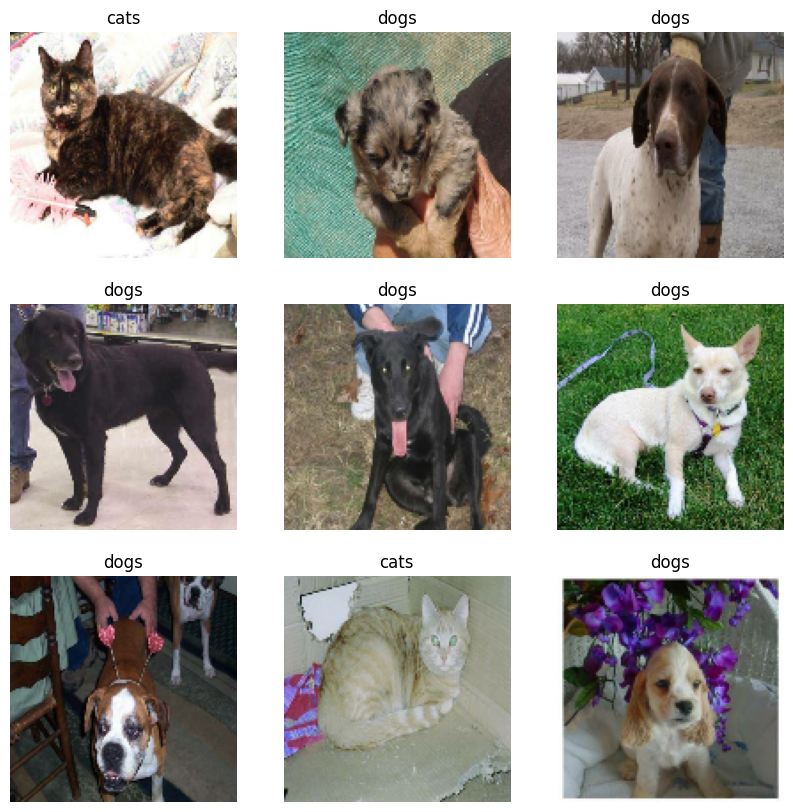

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
    plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

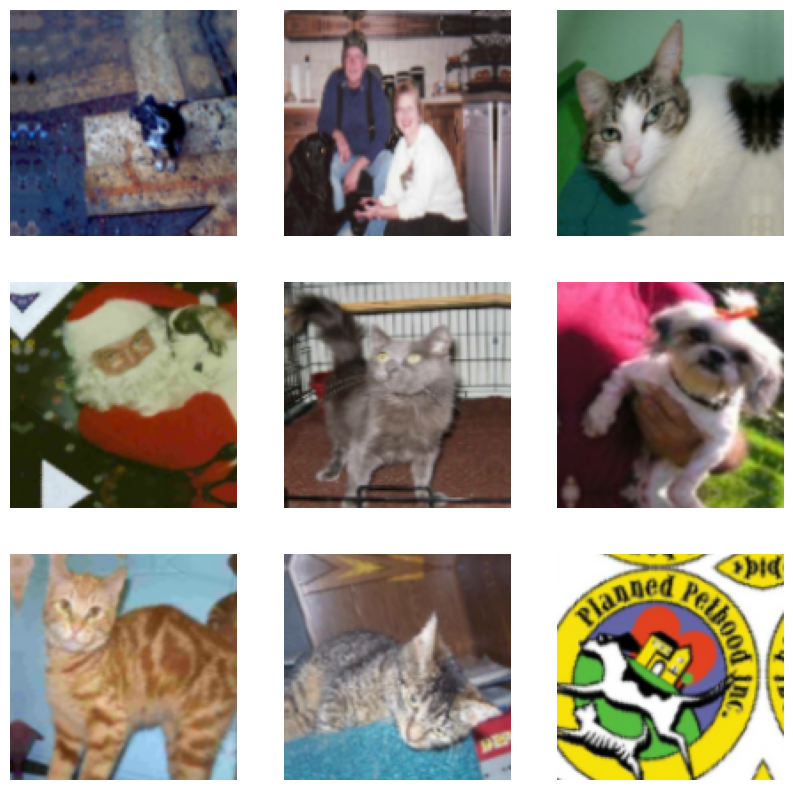

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(images)

    plt.figure(figsize=(10,10))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.show()

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])



In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Compile the model before fitting
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 370ms/step - accuracy: 0.5990 - loss: 0.6595 - val_accuracy: 0.7136 - val_loss: 0.5607
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 369ms/step - accuracy: 0.7302 - loss: 0.5359 - val_accuracy: 0.7880 - val_loss: 0.4566
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 368ms/step - accuracy: 0.7908 - loss: 0.4514 - val_accuracy: 0.8248 - val_loss: 0.3927
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 231s 369ms/step - accuracy: 0.8302 - loss: 0.3843 - val_accuracy: 0.8322 - val_loss: 0.3829
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 371ms/step - accuracy: 0.8594 - loss: 0.3263 - val_accuracy: 0.8466 - val_loss: 0.3553
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 371ms/step - accuracy: 0.8860 - loss: 0.2742 - val_accuracy: 0.8496 - val_loss: 0.3549
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 233s 373ms/step - accuracy: 0.9064 - loss: 0.2245 - val_accuracy: 0.8588 - val_loss: 0.3527
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 233s 373ms/step - accuracy: 0.9266 -